In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
churn=pd.read_csv("D:\data  science\pandas\customer_churn.csv")

In [19]:
churn

,Customer_ID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0
...,...,...,...,...,...,...,...,...,...
495,C00496,50,128,6970,Month-to-month,Credit Card,Yes,1,0
496,C00497,2,49,5917,Two year,Bank Transfer,No,1,0
497,C00498,46,198,2158,Month-to-month,Bank Transfer,No,0,0
498,C00499,1,185,5755,Two year,Credit Card,Yes,1,1


In [21]:
df=pd.read_csv("D:\data  science\pandas\sales_data.csv")

In [23]:
df

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,CUST001,East,261100
1,2024-01-02,Headphones,4,15406,CUST002,North,61624
2,2024-01-03,Phone,2,21746,CUST003,West,43492
3,2024-01-04,Headphones,1,30895,CUST004,East,30895
4,2024-01-05,Laptop,8,39835,CUST005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,CUST096,North,166160
96,2024-04-06,Headphones,1,7647,CUST097,West,7647
97,2024-04-07,Tablet,5,27196,CUST098,East,135980
98,2024-04-08,Monitor,1,30717,CUST099,North,30717


IN BOTH THE DATA SET THE CUSTOMER ID IS WRITTEN IN DIFFERENT FORMAT SO LETS JUST USE A COMMON FORMET TO MERGE BOTH THE DATASET


          IN CHURN DATASET THE CUSTOMER ID IS WRITTEN LIKE C00001
          
          IN SALES DATASET THE CUSTOMER ID IS WRITTEN LIKE CUST001 
          
          WE WILL USE A COMMON WAY WHICH WILL BE C00001

In [25]:
df['Customer_ID'] = df['Customer_ID'].str.replace('CUST','C00')

In [27]:
df

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales
0,2024-01-01,Phone,7,37300,C00001,East,261100
1,2024-01-02,Headphones,4,15406,C00002,North,61624
2,2024-01-03,Phone,2,21746,C00003,West,43492
3,2024-01-04,Headphones,1,30895,C00004,East,30895
4,2024-01-05,Laptop,8,39835,C00005,North,318680
...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,C00096,North,166160
96,2024-04-06,Headphones,1,7647,C00097,West,7647
97,2024-04-07,Tablet,5,27196,C00098,East,135980
98,2024-04-08,Monitor,1,30717,C00099,North,30717


In [29]:
merged = pd.merge(df, churn, on='Customer_ID', how='left')
print(merged.head())

         Date     Product  Quantity  Price Customer_ID Region  Total_Sales  \
0  2024-01-01       Phone         7  37300      C00001   East       261100   
1  2024-01-02  Headphones         4  15406      C00002  North        61624   
2  2024-01-03       Phone         2  21746      C00003   West        43492   
3  2024-01-04  Headphones         1  30895      C00004   East        30895   
4  2024-01-05      Laptop         8  39835      C00005  North       318680   

   Tenure  MonthlyCharges  TotalCharges        Contract     PaymentMethod  \
0       6              64          1540        One year       Credit Card   
1      21             113          1753  Month-to-month  Electronic Check   
2      27              31          1455        Two year       Credit Card   
3      53              29          7150  Month-to-month  Electronic Check   
4      16             185          1023        One year  Electronic Check   

  PaperlessBilling  SeniorCitizen  Churn  
0               No       

In [34]:
merged

,Date,Product,Quantity,Price,Customer_ID,Region,Total_Sales,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,2024-01-01,Phone,7,37300,C00001,East,261100,6,64,1540,One year,Credit Card,No,1,0
1,2024-01-02,Headphones,4,15406,C00002,North,61624,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,2024-01-03,Phone,2,21746,C00003,West,43492,27,31,1455,Two year,Credit Card,No,1,0
3,2024-01-04,Headphones,1,30895,C00004,East,30895,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,2024-01-05,Laptop,8,39835,C00005,North,318680,16,185,1023,One year,Electronic Check,No,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2024-04-05,Tablet,8,20770,C00096,North,166160,20,150,1780,Month-to-month,Electronic Check,Yes,0,0
96,2024-04-06,Headphones,1,7647,C00097,West,7647,15,40,510,Month-to-month,Bank Transfer,No,0,0
97,2024-04-07,Tablet,5,27196,C00098,East,135980,42,172,1168,Month-to-month,Bank Transfer,No,1,0
98,2024-04-08,Monitor,1,30717,C00099,North,30717,10,143,3353,Two year,Electronic Check,No,1,1


In [48]:
merged.describe()
merged["Quantity"].mode()
merged['Price'].mean(), df['Price'].median(), df['Price'].std()



(25808.51, 24192.0, 13917.630241724111)

ACCORDING TO THE DATA 

     THE MEAN PRICE = 25808.15

     THE MEDIAN OF PRICE IS = 24192.0

     THE STD OF PRICE IS = 13917.630241

Not Normal


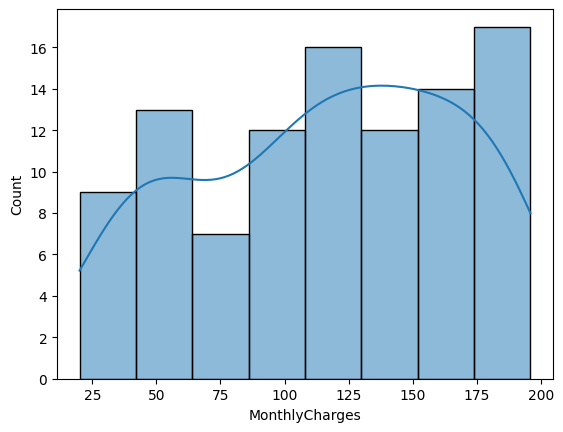

In [44]:

sns.histplot(merged['MonthlyCharges'], kde=True)

from scipy.stats import shapiro
stat, p = shapiro(merged['MonthlyCharges'])
print("Normal" if p > 0.05 else "Not Normal")

THIS HISTOGRAM SHOWS THE MOTHLY CHARGES PATTERN 


         THIS REVEALS THATS THIS PATTERN IS NOT NORMAL 

In [70]:
merged['Churn'] = merged['Churn'].astype(int)   

<Axes: >

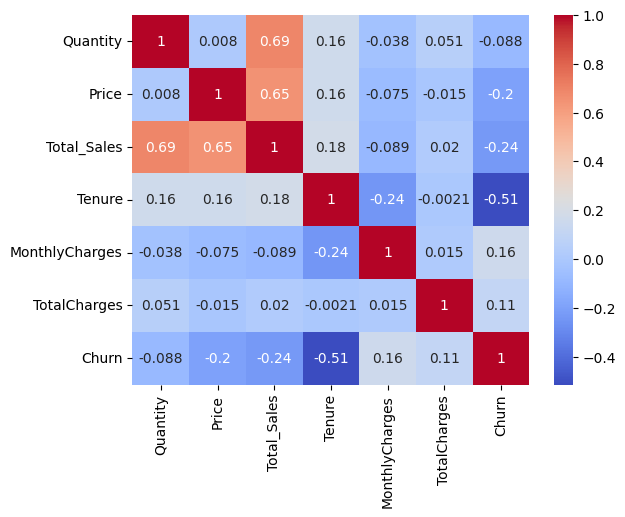

In [74]:
corr = merged[['Quantity','Price','Total_Sales','Tenure','MonthlyCharges','TotalCharges','Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

THE CORELATION REVEALS TO MANY RELATION BETWEEN DATA COLOUMNS

            LETS START WITH CHURN
            CHURN IS HIGHLY DEPENDENT OF TENURE AND TOTAL SALES
            LIKE MONTHLY CHARGES DEPENDS UPON QUATITIY ,PRICE, TOTAT SALES AND TENURE
            LIKE TOTAL CHARGES DEPENDS UPON QUANTITY,PRICE, TOTAT SALES AND TENURE 

In [79]:
from scipy.stats import ttest_ind
churn0 = merged[merged['Churn']==0]['MonthlyCharges']
churn1 = merged[merged['Churn']==1]['MonthlyCharges']
ttest_ind(churn0, churn1)

TtestResult(statistic=-1.598781444932082, pvalue=0.11308845782824027, df=98.0)

In [81]:
from scipy.stats import f_oneway
f_oneway(merged[merged['Region']=='East']['Total_Sales'],
         merged[merged['Region']=='West']['Total_Sales'],
         merged[merged['Region']=='North']['Total_Sales'])

F_onewayResult(statistic=3.3927782582624055, pvalue=0.03923264893168547)

In [89]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=merged['Total_Sales'], groups=merged['Region'], alpha=0.05)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------
  East  North   9660.0996 0.9875  -66841.2004 86161.3997  False
  East  South    5826.384 0.9972   -71245.493  82898.261  False
  East   West -50923.2713 0.3221  -128604.929 26758.3865  False
 North  South  -3833.7156 0.9989  -73255.5603 65588.1291  False
 North   West -60583.3709 0.1149 -130681.5752  9514.8334  False
 South   West -56749.6553 0.1611  -127470.116 13970.8055  False
---------------------------------------------------------------


-  ANOVA showed overall significance (p ≈ 0.039), meaning there is some difference among regions.
- But Tukey’s test shows no single pair of regions differs strongly enough to be significant after adjusting for multiple comparisons.
- The overall difference may be driven by combined variance patterns rather than one clear pairwise gap.




In [87]:
import scipy.stats as stats
contingency = pd.crosstab(merged['Contract'], merged['Churn'])
stats.chi2_contingency(contingency)

Chi2ContingencyResult(statistic=4.074378154837925, pvalue=0.13039472569667715, dof=2, expected_freq=array([[31.5,  3.5],
       [32.4,  3.6],
       [26.1,  2.9]]))

- In plain terms: there’s no strong evidence of an association between the two categorical variables which were tested (likely Contract vs Churn).


In [98]:
import numpy as np, scipy.stats as st
mean = np.mean(merged['MonthlyCharges'])
ci = st.t.interval(0.95, len(merged['MonthlyCharges'])-1, loc=mean, scale=st.sem(merged['MonthlyCharges']))
print(ci)

(106.62685474000713, 126.97314525999286)


Business Insight
- Customers typically pay around ₹117 per month, but it could realistically range from ₹107 to ₹127.
- If you’re setting pricing strategies, this interval gives you a safe range where most customers’ charges fall.
- If churn analysis shows higher churn above ~₹127, you might want to cap or adjust pricing to stay within this comfort zone.



In [103]:
import statsmodels.api as sm
X = merged[['Quantity','Price','Tenure','MonthlyCharges']]
y = merged['Total_Sales']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     184.4
Date:                Wed, 21 Jan 2026   Prob (F-statistic):           7.17e-44
Time:                        16:18:29   Log-Likelihood:                -1184.3
No. Observations:                 100   AIC:                             2379.
Df Residuals:                      95   BIC:                             2392.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const          -1.097e+05   1.47e+04     -7.

- Sales Drivers:
- Focus on increasing product quantity sold and optimizing pricing strategy.
- These two variables explain nearly all sales variation.
- Customer Variables:
- Tenure and MonthlyCharges don’t directly drive sales, but they may matter for churn prediction instead.
- Strategic Recommendation:
- Invest in sales volume growth (bundles, promotions).
- Experiment with pricing elasticity to maximize revenue.
- Use separate models (like logistic regression) for churn/retention analysis.


In [107]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = merged[['Quantity','Price','Tenure','MonthlyCharges']]
[variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

[3.926776888599049, 3.855237847277893, 4.0332146517216145, 3.552238194714653]